In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from keras.datasets import mnist
from torch.utils.data import TensorDataset, DataLoader

# Загрузка датасета MNIST из Keras
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Преобразуем входные данные в тензоры PyTorch
# Нормализация: значения [0,255] → [0.0,1.0], добавляем канал 1 (ч/б)
x_train = torch.tensor(x_train, dtype=torch.float32).unsqueeze(1) / 255.0
x_test = torch.tensor(x_test, dtype=torch.float32).unsqueeze(1) / 255.0

# Преобразуем метки в тензоры long (для CrossEntropy)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

# Создаём TensorDataset и DataLoader для обучения и тестирования
train_dataset = TensorDataset(x_train, y_train)
test_dataset = TensorDataset(x_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


# Определяем простую сверточную нейросеть
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        # Первый сверточный слой: 1 входной канал, 32 выходных, ядро 3x3
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        # Второй сверточный слой: 32 входных канала, 64 выходных, ядро 3x3
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        # Полносвязный слой после сверток и пуллинга
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        # Выходной слой: 10 классов (цифры 0-9)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # Свертка → ReLU → MaxPool
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        # Выравниваем перед подачей в полносвязный слой
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)


# Инициализация модели, функции потерь и оптимизатора
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Обучение модели
for epoch in range(5):  # 5 эпох
    model.train()
    total_loss = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        # Обнуляем градиенты
        optimizer.zero_grad()
        # Прямой проход
        outputs = model(inputs)
        # Вычисляем ошибку
        loss = criterion(outputs, labels)
        # Обратный проход
        loss.backward()
        # Обновляем веса
        optimizer.step()

        total_loss += loss.item()
    print(f"Epoch {epoch + 1}, Loss: {total_loss:.4f}")

# Тестирование модели
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")


Epoch 1, Loss: 164.1606
Epoch 2, Loss: 45.9853
Epoch 3, Loss: 32.1520
Epoch 4, Loss: 24.0156
Epoch 5, Loss: 17.7231
Test Accuracy: 98.98%


Epoch 1, Loss: 0.0160, Accuracy: 99.45%
Epoch 2, Loss: 0.0123, Accuracy: 99.61%
Epoch 3, Loss: 0.0120, Accuracy: 99.62%
Epoch 4, Loss: 0.0084, Accuracy: 99.72%
Epoch 5, Loss: 0.0073, Accuracy: 99.73%


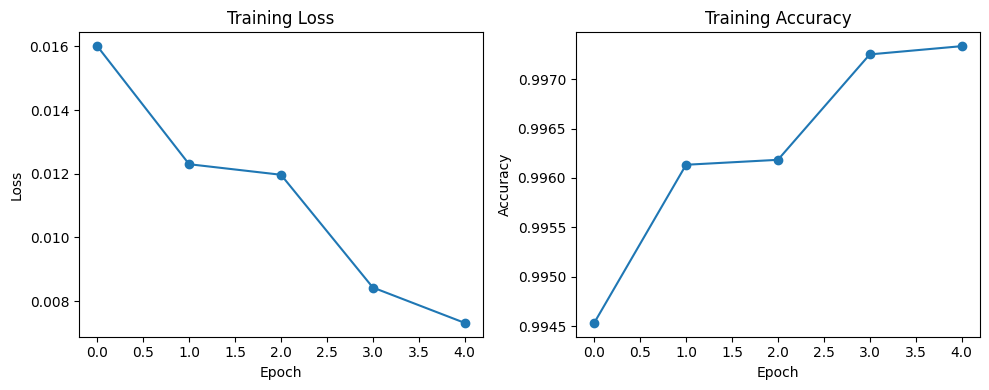

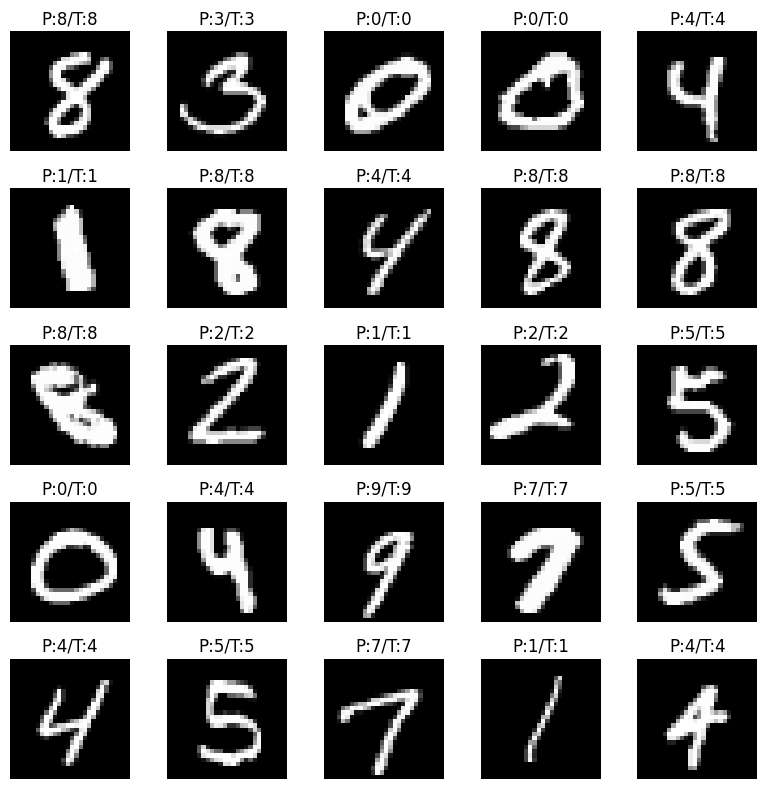

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import random

# Сохраняем потери и точность
train_losses = []
train_accuracies = []

# Обучение с сохранением статистики
for epoch in range(5):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    avg_loss = total_loss / len(train_loader)
    accuracy = correct / total
    train_losses.append(avg_loss)
    train_accuracies.append(accuracy)
    print(f"Epoch {epoch + 1}, Loss: {avg_loss:.4f}, Accuracy: {accuracy * 100:.2f}%")

# --- ГРАФИКИ ---

# График потерь
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, marker='o')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

# График точности
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, marker='o')
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()

# --- ВИЗУАЛИЗАЦИЯ ПРЕДСКАЗАНИЙ ---

# Переводим модель в режим оценки
model.eval()
# Получаем 25 случайных примеров
indices = random.sample(range(len(x_test)), 25)
sample_images = x_test[indices]
sample_labels = y_test[indices]

# Прогоняем через модель
with torch.no_grad():
    outputs = model(sample_images.to(device))
    _, preds = torch.max(outputs, 1)

# Отображаем изображения с предсказаниями
plt.figure(figsize=(8, 8))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(sample_images[i][0], cmap='gray')
    plt.title(f"P:{preds[i].item()}/T:{sample_labels[i].item()}")
    plt.axis('off')
plt.tight_layout()
plt.show()
